# Importing Libraries

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

# Loading Dataset

In [69]:
df = pd.read_csv("booking.csv")

In [70]:
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [72]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [73]:
df=df.drop("Booking_ID",axis=1)

In [74]:
df.columns = [col.replace(" ","_") for col in df.columns]

In [75]:
df.nunique()

number_of_adults               5
number_of_children             6
number_of_weekend_nights       8
number_of_week_nights         18
type_of_meal                   4
car_parking_space              2
room_type                      7
lead_time                    352
market_segment_type            5
repeated                       2
P-C                            9
P-not-C                       59
average_price               3930
special_requests               6
date_of_reservation          553
booking_status                 2
dtype: int64

In [76]:
df["date_of_reservation"][~df["date_of_reservation"].str.contains('/')]

2626     2018-2-29
3677     2018-2-29
5600     2018-2-29
6343     2018-2-29
7648     2018-2-29
8000     2018-2-29
8989     2018-2-29
9153     2018-2-29
9245     2018-2-29
9664     2018-2-29
9934     2018-2-29
10593    2018-2-29
10652    2018-2-29
10747    2018-2-29
11881    2018-2-29
13958    2018-2-29
14304    2018-2-29
15363    2018-2-29
15438    2018-2-29
17202    2018-2-29
18380    2018-2-29
18534    2018-2-29
18680    2018-2-29
19013    2018-2-29
20419    2018-2-29
21674    2018-2-29
21688    2018-2-29
26108    2018-2-29
27559    2018-2-29
27928    2018-2-29
30552    2018-2-29
30616    2018-2-29
30632    2018-2-29
30839    2018-2-29
32041    2018-2-29
34638    2018-2-29
35481    2018-2-29
Name: date_of_reservation, dtype: object

In [77]:
# we used pd.to_datetime("2018-2-29") to see if this day is valid and the result was " day is out of range for month"

In [78]:
mask = pd.to_datetime(df["date_of_reservation"],errors="coerce").isna()
df = df[~mask]

In [79]:
df["booking_status"] = df["booking_status"].map({"Not_Canceled":0,"Canceled":1})

In [80]:
import datetime as dt
df["date_of_reservation"] = pd.to_datetime(df["date_of_reservation"])
df["day"] = df["date_of_reservation"].dt.day
df["month"] = df["date_of_reservation"].dt.month
df["year"] = df["date_of_reservation"].dt.year

In [81]:
df = df.drop("date_of_reservation",axis=1)

In [82]:
df.head()

,number_of_adults,number_of_children,number_of_weekend_nights,number_of_week_nights,type_of_meal,car_parking_space,room_type,lead_time,market_segment_type,repeated,P-C,P-not-C,average_price,special_requests,booking_status,day,month,year
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,0,2,10,2015
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,0,6,11,2018
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,1,28,2,2018
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,1,20,5,2017
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,1,11,4,2018


In [83]:
object_col = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df,columns=object_col,drop_first=True).astype("int")

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36248 entries, 0 to 36284
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   number_of_adults                   36248 non-null  int64
 1   number_of_children                 36248 non-null  int64
 2   number_of_weekend_nights           36248 non-null  int64
 3   number_of_week_nights              36248 non-null  int64
 4   car_parking_space                  36248 non-null  int64
 5   lead_time                          36248 non-null  int64
 6   repeated                           36248 non-null  int64
 7   P-C                                36248 non-null  int64
 8   P-not-C                            36248 non-null  int64
 9   average_price                      36248 non-null  int64
 10  special_requests                   36248 non-null  int64
 11  booking_status                     36248 non-null  int64
 12  day                    

# Exploratory Data Analysis

In [92]:
df.corr(numeric_only=True)["booking_status"].sort_values(ascending=False)

booking_status                       1.000000
lead_time                            0.438583
year                                 0.179431
average_price                        0.142254
market_segment_type_Online           0.106131
number_of_week_nights                0.092732
type_of_meal_Meal Plan 2             0.086647
number_of_adults                     0.086525
number_of_weekend_nights             0.061630
number_of_children                   0.032962
room_type_Room_Type 6                0.032876
room_type_Room_Type 4                0.013317
day                                  0.011195
type_of_meal_Not Selected            0.002878
room_type_Room_Type 2                0.000500
room_type_Room_Type 3               -0.001246
type_of_meal_Meal Plan 3            -0.003198
room_type_Room_Type 5               -0.009841
month                               -0.012007
room_type_Room_Type 7               -0.014088
P-C                                 -0.033868
market_segment_type_Offline       

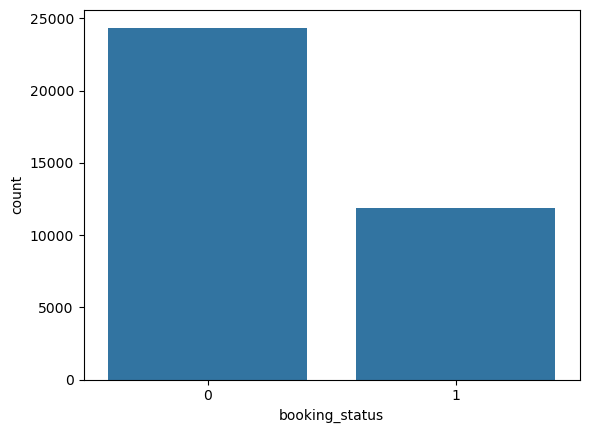

In [96]:
sns.countplot(x="booking_status", data=df)
plt.show()

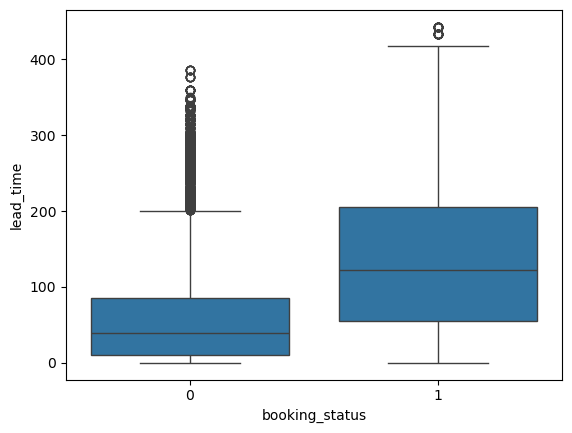

In [95]:
sns.boxplot(data=df,x="booking_status",y="lead_time")
plt.show()

In [97]:
df.groupby("booking_status")["average_price].mean()

booking_status
0     99.686530
1    110.310638
Name: average_price, dtype: float64

# Standardizing Variables

In [99]:
scaler = StandardScaler()
y = df["booking_status"]
X = df.drop("booking_status",axis=1)
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

In [100]:
X_scaled.head()

,number_of_adults,number_of_children,number_of_weekend_nights,number_of_week_nights,car_parking_space,lead_time,repeated,P-C,P-not-C,average_price,...,room_type_Room_Type 2,room_type_Room_Type 3,room_type_Room_Type 4,room_type_Room_Type 5,room_type_Room_Type 6,room_type_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,-1.629530,2.222348,1.365851,1.981487,-0.178641,1.613740,-0.161913,-0.063348,-0.087228,-0.432691,...,-0.139507,-0.013898,-0.447643,-0.08549,-0.165291,-0.066166,-0.104289,-0.242358,1.563745,-1.333515
1,-1.629530,-0.261562,0.217648,0.563857,-0.178641,-0.933946,-0.161913,-0.063348,-0.087228,0.080750,...,-0.139507,-0.013898,-0.447643,-0.08549,-0.165291,-0.066166,-0.104289,-0.242358,-0.639490,0.749898
2,0.298503,2.222348,0.217648,0.563857,-0.178641,-0.980479,-0.161913,-0.063348,-0.087228,-1.516623,...,-0.139507,-0.013898,-0.447643,-0.08549,-0.165291,-0.066166,-0.104289,-0.242358,-0.639490,0.749898
3,-1.629530,-0.261562,-0.930555,-0.144958,-0.178641,1.462507,-0.161913,-0.063348,-0.087228,-0.090397,...,-0.139507,-0.013898,-0.447643,-0.08549,-0.165291,-0.066166,-0.104289,-0.242358,-0.639490,0.749898
4,-1.629530,-0.261562,0.217648,-0.144958,-0.178641,-0.433716,-0.161913,-0.063348,-0.087228,-0.746461,...,-0.139507,-0.013898,-0.447643,-0.08549,-0.165291,-0.066166,-0.104289,-0.242358,-0.639490,0.749898


# Creating and Training The model

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.30)
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


# Prediction and Evaluation

In [102]:
pred = model.predict(X_test)
print(confusion_matrix(y_test,pred))

[[6413  881]
 [ 905 2676]]


In [103]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7294
           1       0.75      0.75      0.75      3581

    accuracy                           0.84     10875
   macro avg       0.81      0.81      0.81     10875
weighted avg       0.84      0.84      0.84     10875



# Choosing The Best K

Text(0, 0.5, 'Error Rate')

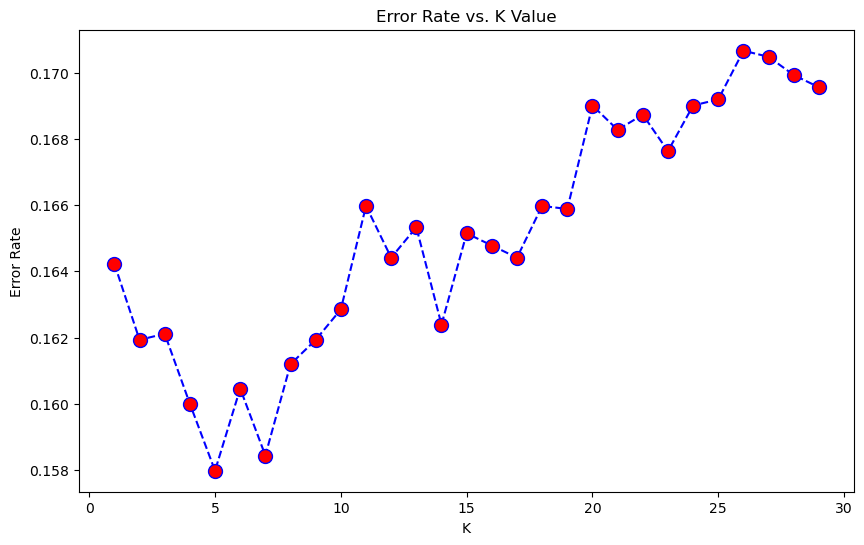

In [107]:
error_rate = []
for i in range(1,30):    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
plt.figure(figsize=(10,6))
plt.plot(range(1,30),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [ ]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
pred = model.predict(X_test)

In [108]:
print(f"accuracy score {accuracy_score(y_test,pred)}")
print(classification_report(y_test,pred))

accuracy score 0.8357701149425287
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      7294
           1       0.75      0.75      0.75      3581

    accuracy                           0.84     10875
   macro avg       0.81      0.81      0.81     10875
weighted avg       0.84      0.84      0.84     10875

